In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
from matplotlib import cm


INPUT_ROOT = Path("/home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda")

SR_ORIGINAL = 50000
SR_TARGET = 16000

MIC_COLUMN_INDEX = 7
WINDOW = 1.0
OVERLAP = 0.5

#csv_files = sorted(csv_path.rglob("*.csv"))
csv_files = list(INPUT_ROOT.rglob("*.csv"))

print("Number of CSV files found:", len(csv_files))

# Show the first few files
for path in csv_files[:5]:
    print(path)


Number of CSV files found: 1951
/home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda/normal/55.7056.csv
/home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda/normal/40.3456.csv
/home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda/normal/14.336.csv
/home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda/normal/29.4912.csv
/home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda/normal/44.6464.csv


In [15]:
if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found under {INPUT_ROOT}")

sample_path = csv_files[0]
sample_df = pd.read_csv(sample_path, header=None)

print("Sample file:", sample_path)
print("Shape:", sample_df.shape)
print("Number of columns:", sample_df.shape[1])

if sample_df.shape[1] <= MIC_COLUMN_INDEX:
    raise ValueError(
        f"Expected at least {MIC_COLUMN_INDEX + 1} columns, "
        f"but this file has only {sample_df.shape[1]} columns. "
        "Check the CSV separator, for example sep=';' or sep='\\t'."
    )

print("\nFirst 5 values from the selected 8th column:")
display(sample_df.iloc[:5, MIC_COLUMN_INDEX])


Sample file: /home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda/normal/55.7056.csv
Shape: (250000, 8)
Number of columns: 8

First 5 values from the selected 8th column:


0   -0.163260
1    0.047972
2   -0.116110
3   -0.027671
4   -0.029934
Name: 7, dtype: float64

A window is a short segment cut from the audio signal. we are splitting each audio signal into wondows of 1 second. 

`SR_ORIGINAL=50000`, one second of audio contains 50000 samples. 

each window is 50000 values (of the csv column).

the windows overlap by 50% (0.5).

Ex: 
Window 1: 0.0s to 1.0s
Window 2: 0.5s to 1.5s
Window 3: 1.0s to 2.0s
Window 4: 1.5s to 2.5s




In [16]:
def load_mic(csv_path, mic_column_index=MIC_COLUMN_INDEX):
    """Load only the microphone/audio column from one CSV file."""
    df = pd.read_csv(csv_path, header=None)

    if df.shape[1] <= mic_column_index:
        raise ValueError(
            f"{csv_path} has {df.shape[1]} columns, "
            f"but column index {mic_column_index} was requested. "
            "Check whether the CSV separator is correct."
        )

    # Select only the 8th column when mic_column_index = 7
    audio = df.iloc[:, mic_column_index].to_numpy(dtype=np.float32)

    # Remove DC offset
    audio = audio - np.mean(audio)

    # Normalize to approximately [-1, 1]
    audio = audio / (np.max(np.abs(audio)) + 1e-8)

    return audio


def split_windows(signal, sr, window_seconds=1.0, overlap=0.5):
    """Split a 1D signal into overlapping windows."""
    window_size = int(sr * window_seconds)
    step = int(window_size * (1 - overlap))

    if step <= 0:
        raise ValueError("overlap must be less than 1.0")

    windows = []

    for start in range(0, len(signal) - window_size + 1, step):
        windows.append(signal[start:start + window_size])

    return windows


def make_logmel_tinyml(audio_window):
    """Convert one audio window into a log-mel spectrogram."""
    audio_window = librosa.resample(
        audio_window,
        orig_sr=SR_ORIGINAL,
        target_sr=SR_TARGET
    )

    mel = librosa.feature.melspectrogram(
        y=audio_window,
        sr=SR_TARGET,
        n_fft=512,
        hop_length=160,
        n_mels=40
    )

    logmel = librosa.power_to_db(mel, ref=np.max)

    return logmel.astype(np.float32)


X - many log-mel spectrograms extracted from the 8th column of all CSV files


In [ ]:
X = [] #input data (audio features)
y = [] # label for each item in X
file_paths = []

for csv_path in csv_files:
    # Label = first folder after INPUT_ROOT
    label = csv_path.relative_to(INPUT_ROOT).parts[0]

    audio = load_mic(csv_path)
    windows = split_windows(
        audio,
        sr=SR_ORIGINAL,
        window_seconds=WINDOW,
        overlap=OVERLAP
    )

    for window in windows:
        logmel = make_logmel_tinyml(window)

        X.append(logmel)
        y.append(label)
        file_paths.append(str(csv_path))

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of file paths:", len(file_paths))
print("Labels:", sorted(set(y)))


X shape: (17559, 40, 101)
y shape: (17559,)
Number of file paths: 17559
Labels: [np.str_('horizontal-misalignment'), np.str_('imbalance'), np.str_('normal'), np.str_('overhang'), np.str_('underhang'), np.str_('vertical-misalignment')]


17559 windows/examples
40 mel-frequency bands
101 time frames

horizontal-misalignment    1773
imbalance                  2997
normal                      441
overhang                   4617
underhang                  5022
vertical-misalignment      2709
Name: count, dtype: int64

<Axes: title={'center': 'Number of windows per label'}>

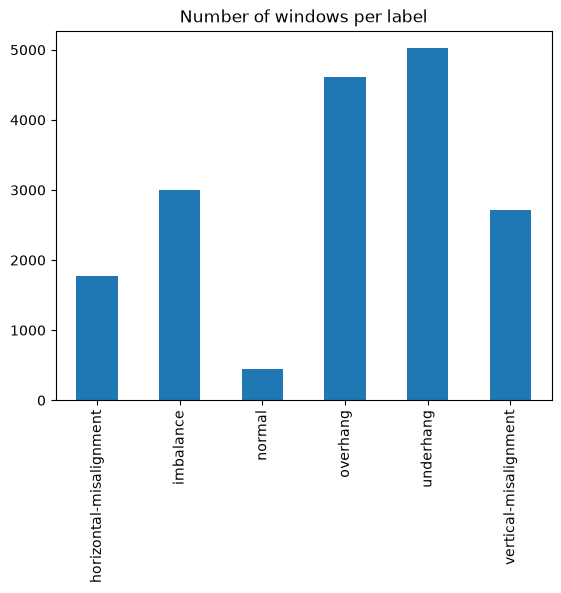

In [ ]:
# how many audio windows were created for each class/label.
label_counts = pd.Series(y).value_counts().sort_index()
display(label_counts)

label_counts.plot(kind="bar", title="Number of windows per label")


1773 log-mel examples from horizontal-misalignment
2997 log-mel examples from imbalance
441 log-mel examples from normal
4617 log-mel examples from overhang
5022 log-mel examples from underhang
2709 log-mel examples from vertical-misalignment

In [19]:
labels_sorted = sorted(set(y))
label_to_id = {label: idx for idx, label in enumerate(labels_sorted)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

y_encoded = np.array([label_to_id[label] for label in y], dtype=np.int64)

print("Label to ID mapping:")
for label, idx in label_to_id.items():
    print(f"{idx}: {label}")

print("y_encoded shape:", y_encoded.shape)


Label to ID mapping:
0: horizontal-misalignment
1: imbalance
2: normal
3: overhang
4: underhang
5: vertical-misalignment
y_encoded shape: (17559,)


In [20]:
OUTPUT_PATH = INPUT_ROOT.parent / "mafaulda_logmel_features.npz"

np.savez_compressed(
    OUTPUT_PATH,
    X=X,
    y=y,
    y_encoded=y_encoded,
    file_paths=np.array(file_paths),
    labels=np.array(labels_sorted)
)

print("Saved to:", OUTPUT_PATH)

Saved to: /home/aicha/Documents/UFSC/26.1/IAnaBorda/archive/mafaulda_logmel_features.npz
